In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_3d_counts_to_cf
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
import matplotlib.gridspec as gridspec
from astropy.cosmology import FlatLambdaCDM
import astropy.cosmology.units as cu
import astropy.units as u
from astropy.io import fits
import quaia
from astropy.coordinates import SkyCoord

In [2]:
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['legend.fontsize'] = 18

plt.rcParams['axes.titlesize'] = 20

In [3]:
cmap_map = 'plasma'

# Load data from local machine

In [4]:
fn_gcatlo = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock1.fits'
fn_gcathi = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20.5/mock_catalog_quaia_G20.5_mock1.fits'

fn_gcatlo_nosel = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_nosel_G20_mock1.fits'
fn_gcathi_nosel = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20.5/mock_catalog_quaia_nosel_G20.5_mock1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
name_catalog = '$Gaia$-$unWISE$ Quasar Mock Catalog'
abbrv_catalog = 'Quaia'

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
# for plotting purposes
fac_stdev = 0.5 #1.45 # 1.5

## Quasar mock catalog

In [10]:
tab_gcatlo = Table.read(fn_gcatlo)
N_gcatlo = len(tab_gcatlo)
print(f"Number of data sources: {N_gcatlo}")

Number of data sources: 755512


In [11]:
print(tab_gcatlo.meta)

OrderedDict()


In [12]:
print(f"Column names: {tab_gcatlo.columns}")

Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


In [13]:
tab_gcathi = Table.read(fn_gcathi)
N_gcathi = len(tab_gcathi)
print(f"Number of data sources: {N_gcathi}")

Number of data sources: 1295221


In [14]:
tab_gcatlo_nosel = Table.read(fn_gcatlo_nosel)
N_gcatlo_nosel = len(tab_gcatlo_nosel)
print(f"Number of data sources: {N_gcatlo_nosel}")

Number of data sources: 755512


In [15]:
tab_gcathi_nosel = Table.read(fn_gcathi_nosel)
N_gcathi_nosel = len(tab_gcathi_nosel)
print(f"Number of data sources: {N_gcathi_nosel}")

Number of data sources: 1295221


### Make map of quasar number counts

In [16]:
# mask the plane
mask = 20
c_gcatlo = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree)
mask_gcatlo = np.abs(c_gcatlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcatlo_mask = len(tab_gcatlo['ra'][mask_gcatlo])

In [17]:
pixel_indices_gcatlo_mask = hp.ang2pix(NSIDE, tab_gcatlo['ra'][mask_gcatlo], tab_gcatlo['dec'][mask_gcatlo], lonlat=True)
map_gcatlo = np.bincount(pixel_indices_gcatlo_mask, minlength=NPIX)

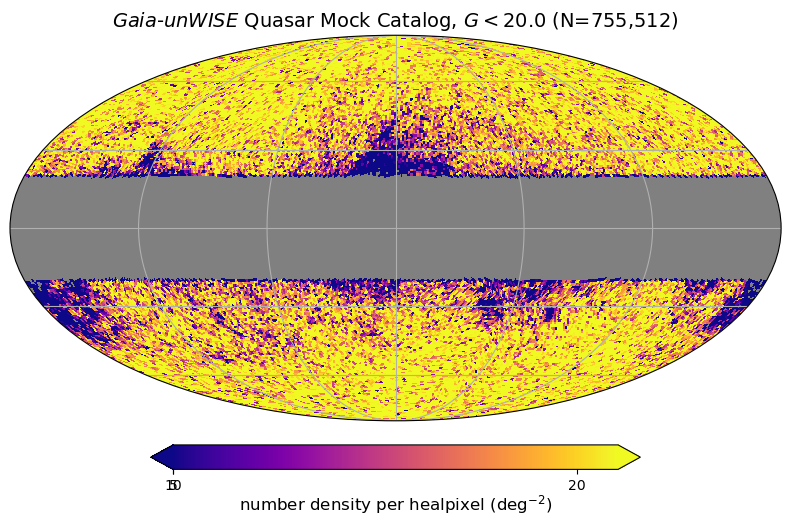

In [18]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_gcatlo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.median(map_gcatlo)+fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [19]:
# mask the plane
c_gcathi = SkyCoord(ra=tab_gcathi['ra']*u.degree, dec=tab_gcathi['dec']*u.degree)
mask_gcathi = np.abs(c_gcathi.galactic.b.value)>=mask # use galactic coordinates from data 
N_gcathi_mask = len(tab_gcathi['ra'][mask_gcathi])

In [20]:
pixel_indices_gcathi_mask = hp.ang2pix(NSIDE, tab_gcathi['ra'][mask_gcathi], tab_gcathi['dec'][mask_gcathi], lonlat=True)
map_gcathi = np.bincount(pixel_indices_gcathi_mask, minlength=NPIX)

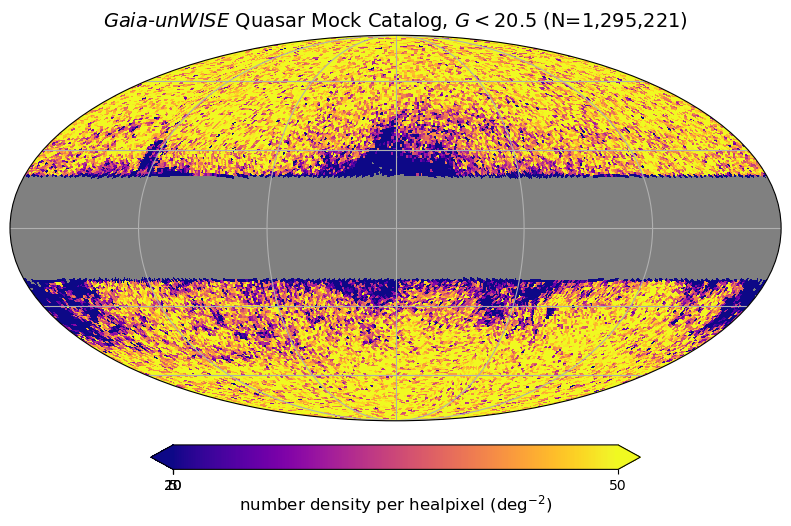

In [21]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_gcathi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi)-fac_stdev*np.std(map_gcathi), max=np.median(map_gcathi)+fac_stdev*np.std(map_gcathi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 50])

#### Without the selection function

In [22]:
pixel_indices_gcatlo_nosel = hp.ang2pix(NSIDE, tab_gcatlo_nosel['ra'], tab_gcatlo_nosel['dec'], lonlat=True)
map_gcatlo_nosel = np.bincount(pixel_indices_gcatlo_nosel, minlength=NPIX)

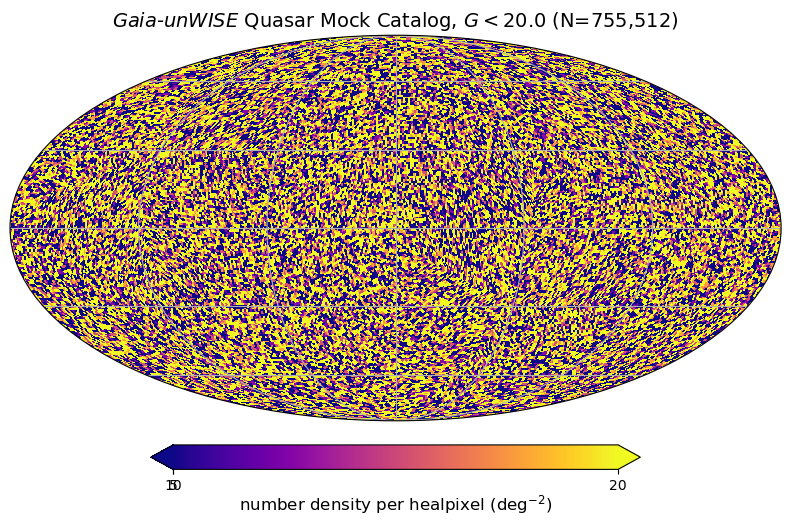

In [23]:
title_gcatlo_nosel = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo_nosel):,})"
projview(map_gcatlo_nosel, title=title_gcatlo_nosel,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo_nosel)-fac_stdev*np.std(map_gcatlo_nosel), max=np.median(map_gcatlo_nosel)+fac_stdev*np.std(map_gcatlo_nosel), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [24]:
pixel_indices_gcathi_nosel = hp.ang2pix(NSIDE, tab_gcathi_nosel['ra'], tab_gcathi_nosel['dec'], lonlat=True)
map_gcathi_nosel = np.bincount(pixel_indices_gcathi_nosel, minlength=NPIX)

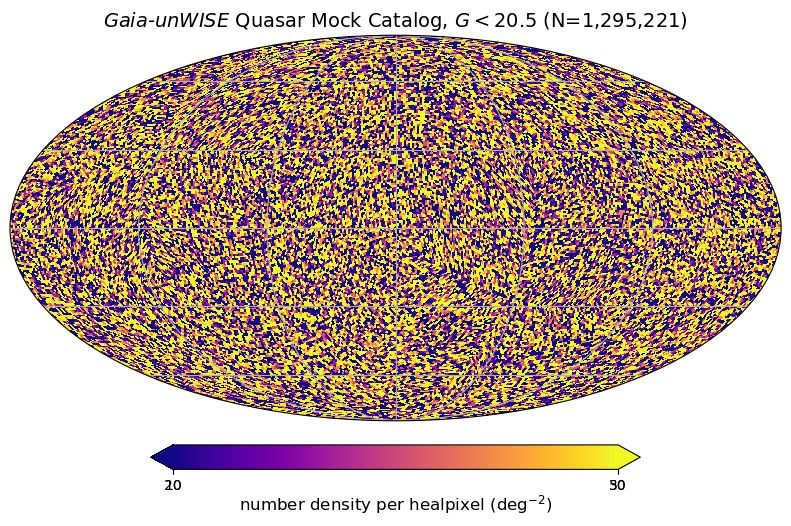

In [25]:
title_gcathi_nosel = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi_nosel):,})"
projview(map_gcathi_nosel, title=title_gcathi_nosel,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi_nosel)-fac_stdev*np.std(map_gcathi_nosel), max=np.median(map_gcathi_nosel)+fac_stdev*np.std(map_gcathi_nosel), 
            norm='log', graticule=True,
            cbar_ticks=[10, 20, 30, 50])

## Random catalog

In [26]:
tab_randlo = Table.read(fn_randlo)
N_randlo = len(tab_randlo)
print(f"Number of random sources: {N_randlo}")

Number of random sources: 7563151


In [27]:
print(f"Column names: {tab_randlo.columns}")

Column names: <TableColumns names=('ra','dec','ebv')>


In [28]:
tab_randhi = Table.read(fn_randhi)
N_randhi = len(tab_randhi)
print(f"Number of random sources: {N_randhi}")

Number of random sources: 12955802


### Make maps of random number counts

In [29]:
c_randlo = SkyCoord(ra=tab_randlo['ra'], dec=tab_randlo['dec'])
mask_randlo = np.abs(c_randlo.galactic.b.value)>=mask # use galactic coordinates from data 
N_randlo_mask = len(tab_randlo['ra'][mask_randlo])

In [30]:
pixel_indices_randlo_mask = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo], tab_randlo['dec'][mask_randlo], lonlat=True)
map_randlo = np.bincount(pixel_indices_randlo_mask, minlength=NPIX)

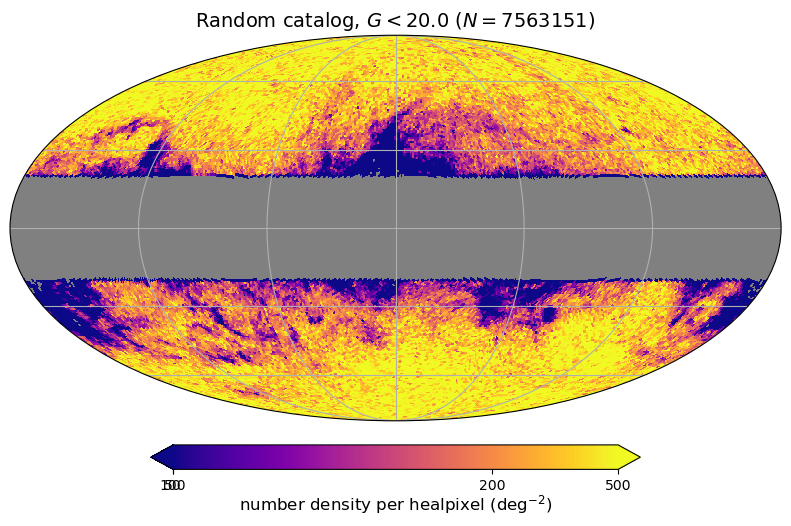

In [31]:
projview(map_randlo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randlo)-fac_stdev*np.std(map_randlo), 
            max=np.median(map_randlo)+fac_stdev*np.std(map_randlo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 100, 200, 500]) 

In [32]:
c_randhi = SkyCoord(ra=tab_randhi['ra'], dec=tab_randhi['dec'])
mask_randhi = np.abs(c_randhi.galactic.b.value)>=mask # use galactic coordinates from data 
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])

In [33]:
pixel_indices_randhi_mask = hp.ang2pix(NSIDE, tab_randhi['ra'][mask_randhi], tab_randhi['dec'][mask_randhi], lonlat=True)
map_randhi = np.bincount(pixel_indices_randhi_mask, minlength=NPIX)

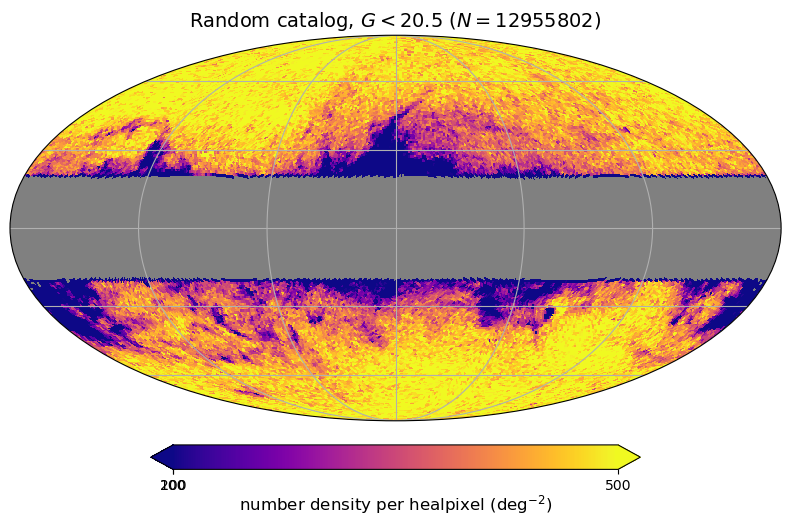

In [34]:
projview(map_randhi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randhi)-fac_stdev*np.std(map_randhi), max=np.median(map_randhi)+fac_stdev*np.std(map_randhi), 
            norm='log', graticule=True,
            cbar_ticks=[100, 200, 500]) 

## Remove the selection function

In [35]:
tab_sello = Table.read(fn_sello)
N_sello = len(tab_sello)
print(f"Number of data sources: {N_sello}")

Number of data sources: 48


In [36]:
print(tab_sello.meta)

OrderedDict([('PIXTYPE', 'HEALPIX'), ('ORDERING', 'RING'), ('EXTNAME', 'xtension'), ('NSIDE', 64), ('FIRSTPIX', 0), ('LASTPIX', 49151), ('INDXSCHM', 'IMPLICIT'), ('OBJECT', 'FULLSKY')])


In [37]:
print(f"Column names: {tab_sello.columns}")

Column names: <TableColumns names=('T')>


In [38]:
tab_selhi = Table.read(fn_selhi)
N_selhi = len(tab_selhi)
print(f"Number of data sources: {N_selhi}")

Number of data sources: 48


In [39]:
print(tab_selhi.meta)

OrderedDict([('PIXTYPE', 'HEALPIX'), ('ORDERING', 'RING'), ('EXTNAME', 'xtension'), ('NSIDE', 64), ('FIRSTPIX', 0), ('LASTPIX', 49151), ('INDXSCHM', 'IMPLICIT'), ('OBJECT', 'FULLSKY')])


In [40]:
print(f"Column names: {tab_selhi.columns}")

Column names: <TableColumns names=('T')>


### Start with data catalogs

In [41]:
selfunc_lo = hp.fitsfunc.read_map(fn_sello)

In [42]:
map_selfunc_lo = map_gcatlo/selfunc_lo

/tmp/ipykernel_28457/515644528.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


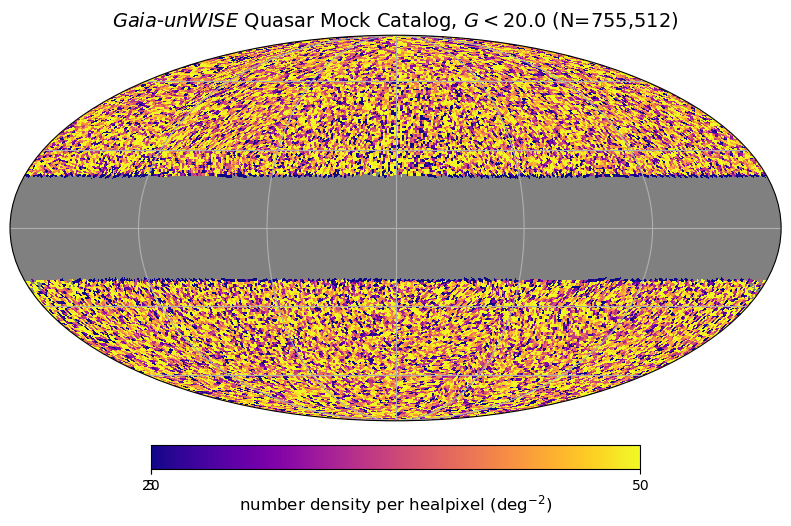

In [43]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_selfunc_lo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_lo)-fac_stdev*np.nanstd(map_selfunc_lo), max=np.nanmedian(map_selfunc_lo)+fac_stdev*np.nanstd(map_selfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 20, 50]) 

In [44]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [45]:
map_selfunc_hi = map_gcathi/selfunc_hi

/tmp/ipykernel_28457/189966545.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_hi = map_gcathi/selfunc_hi


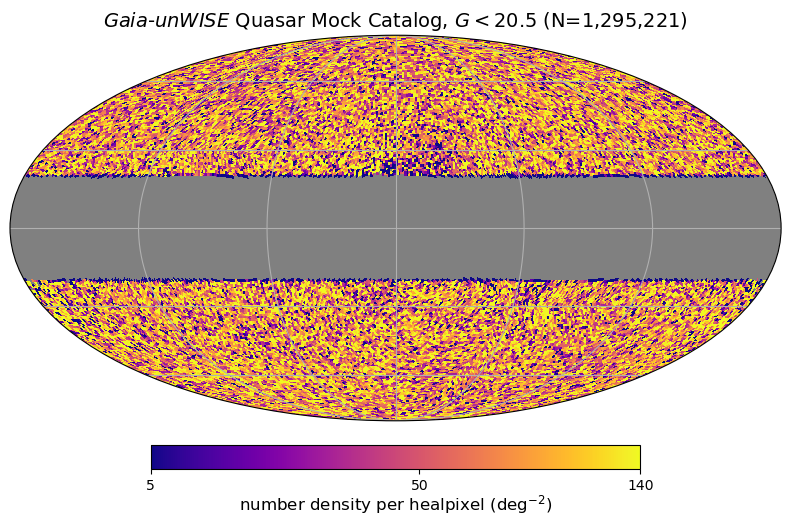

In [46]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_selfunc_hi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_hi)-fac_stdev*np.nanstd(map_selfunc_hi), max=np.nanmedian(map_selfunc_hi)+fac_stdev*np.nanstd(map_selfunc_hi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 50, 140]) 

### Now random catalog

In [47]:
map_randselfunc_lo = map_randlo/selfunc_lo

/tmp/ipykernel_28457/1639919514.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_lo = map_randlo/selfunc_lo


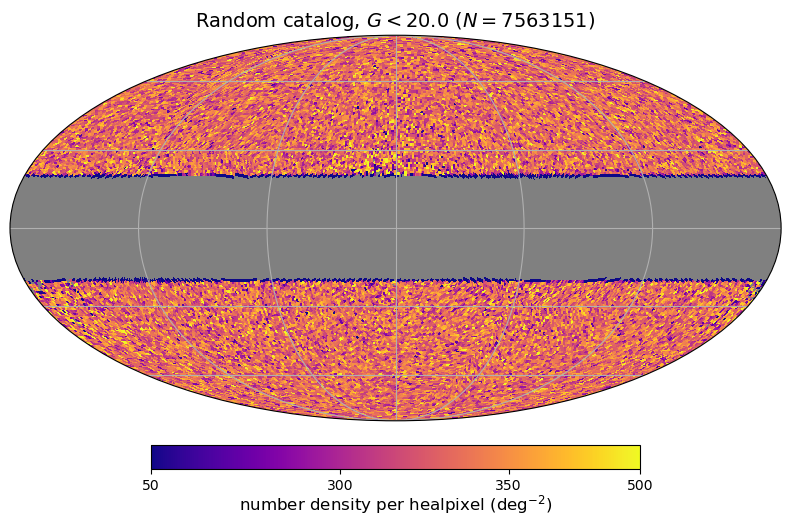

In [48]:
projview(map_randselfunc_lo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_randselfunc_lo)-fac_stdev*np.nanstd(map_randselfunc_lo), 
            max=np.nanmedian(map_randselfunc_lo)+fac_stdev*np.nanstd(map_randselfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 300, 350, 500]) 

In [49]:
map_randselfunc_hi = map_randhi/selfunc_hi

/tmp/ipykernel_28457/231715387.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_hi = map_randhi/selfunc_hi


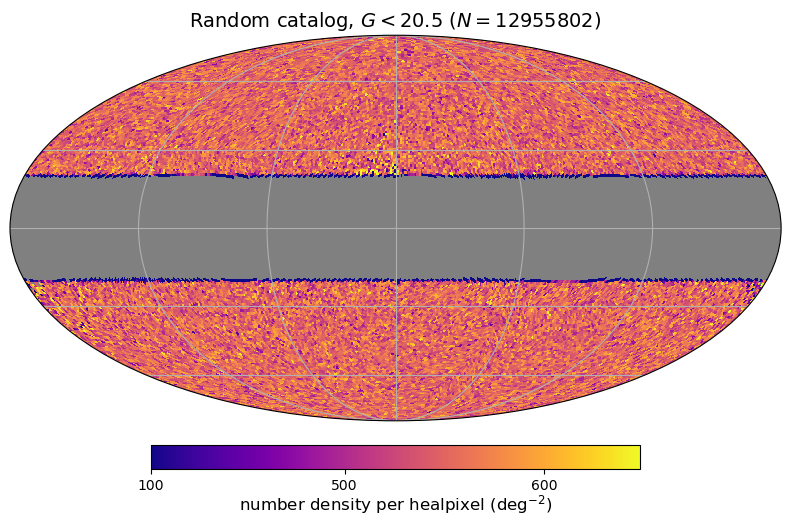

In [50]:
projview(map_randselfunc_hi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
         unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_randselfunc_hi)-fac_stdev*np.nanstd(map_randselfunc_hi), 
         max=np.nanmedian(map_randselfunc_hi)+fac_stdev*np.nanstd(map_randselfunc_hi), norm='log', graticule=True, 
         cbar_ticks=[100, 500, 600]) 

# Compute the 2D angular auto-power spectrum
## First measure the pair counts

In [51]:
# Create the bins array
thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) #np.log10(0.1), np.log10(35) #(np.log10(0.15), np.log10(35), 15)

In [52]:
nthreads = 18

In [53]:
# comoving distance
DD_counts, api_time = mocks.DDtheta_mocks(autocorr = 1, nthreads = nthreads, binfile = thetabins, RA1 = tab_gcatlo['ra'][mask_gcatlo], 
                                          DEC1 = tab_gcatlo['dec'][mask_gcatlo], weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask],
                                          weight_type='pair_product', c_api_timer = True)

api_time

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


1.263477

## Now measure clustering in random catalog

In [54]:
DR_counts, api_time = mocks.DDtheta_mocks(autocorr = 0, nthreads = nthreads, binfile = thetabins, RA1 = tab_gcatlo['ra'][mask_gcatlo], 
                                          DEC1 = tab_gcatlo['dec'][mask_gcatlo], weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], 
                                          RA2 = tab_randlo['ra'][mask_randlo], DEC2 = tab_randlo['dec'][mask_randlo], 
                                          weights2 = 1/selfunc_lo[pixel_indices_randlo_mask], weight_type='pair_product', 
                                          c_api_timer = True)

api_time

27.666175

In [55]:
RR_counts, api_time = mocks.DDtheta_mocks(autocorr = 1, nthreads = nthreads, binfile = thetabins, RA1 = tab_randlo['ra'][mask_randlo], 
                                         DEC1 = tab_randlo['dec'][mask_randlo], weights1 = 1/selfunc_lo[pixel_indices_randlo_mask], 
                                         weight_type='pair_product', c_api_timer = True)

api_time

117.323861

### Plot for sanity check

In [56]:
DD_counts['thetaavg'] = np.mean([DD_counts['thetamin'], DD_counts['thetamax']], axis = 0)
DR_counts['thetaavg'] = np.mean([DR_counts['thetamin'], DR_counts['thetamax']], axis = 0)
RR_counts['thetaavg'] = np.mean([RR_counts['thetamin'], RR_counts['thetamax']], axis = 0)

In [57]:
DD_counts['npairs'] = DD_counts['npairs']*DD_counts['weightavg']
DR_counts['npairs'] = DR_counts['npairs']*DR_counts['weightavg']
RR_counts['npairs'] = RR_counts['npairs']*RR_counts['weightavg']

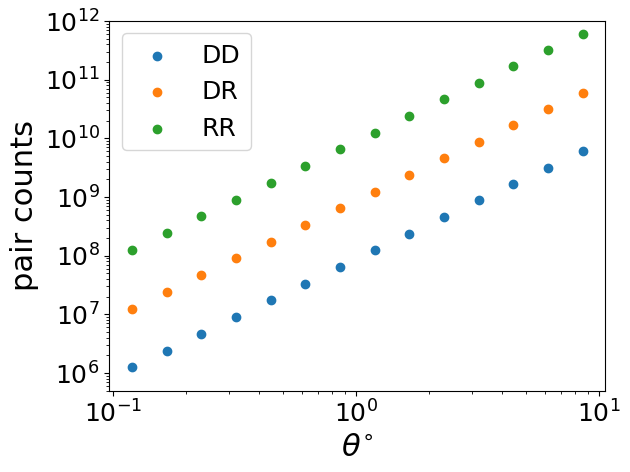

In [58]:
plt.scatter(quaia.recenter(thetabins), DD_counts['npairs'], label = 'DD')
plt.scatter(quaia.recenter(thetabins), DR_counts['npairs'], label = 'DR')
plt.scatter(quaia.recenter(thetabins), RR_counts['npairs'], label = 'RR')
plt.xlabel(r'$\theta^{\circ}$') 
plt.ylabel('pair counts')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5e5, 1e12)
plt.legend()
plt.show()

### Now convert the 2-D pair counts into a $w(\theta)$


In [59]:
# All the pair counts are done, get the angular correlation function
wp = convert_3d_counts_to_cf(N_gcatlo_mask, N_gcatlo_mask, N_randlo_mask, N_randlo_mask, DD_counts, DR_counts, DR_counts, RR_counts)

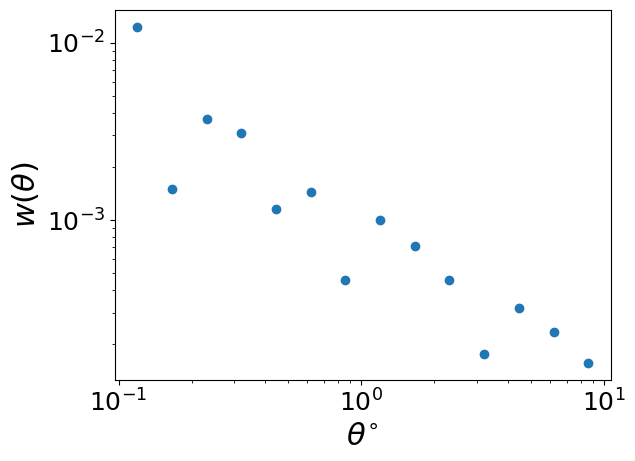

In [60]:
plt.scatter(quaia.recenter(thetabins), wp)
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.show()

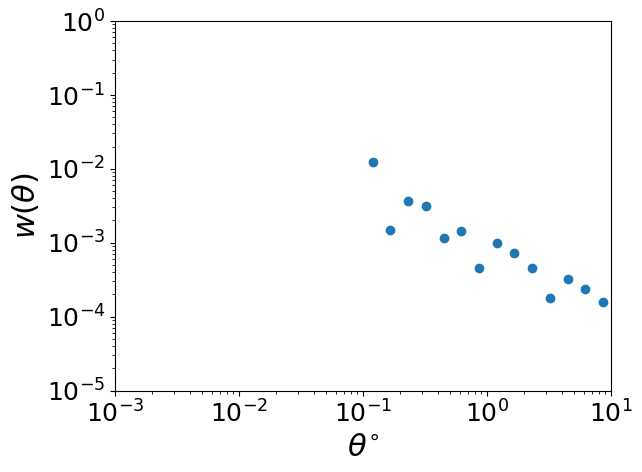

In [61]:
plt.scatter(quaia.recenter(thetabins), wp)
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xlim(1e-3, 10)
plt.ylim(1e-5, 1)
plt.xscale('log')
plt.yscale('log')
plt.show()

### Compare to https://arxiv.org/abs/2108.03640
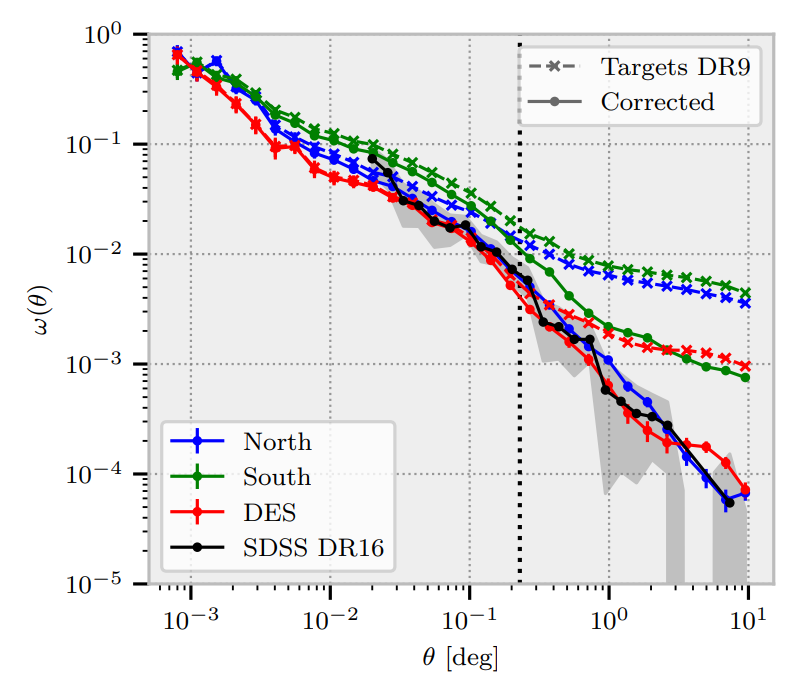

### Compare to data

In [62]:
wp_mock = quaia.w_theta(tab_gcatlo[mask_gcatlo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask, pixel_indices_randlo_mask, 
                        N_gcatlo_mask, N_randlo_mask, RR_counts, nthreads = nthreads, thetabins = thetabins)

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:220: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
  weights2 = 1/selfunc_lo[pixel_indices_randlo], weight_type='pair_product',


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])


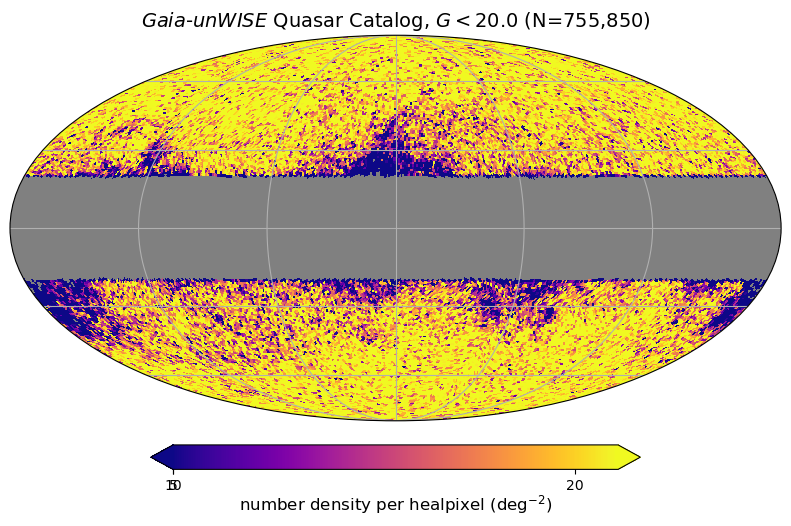

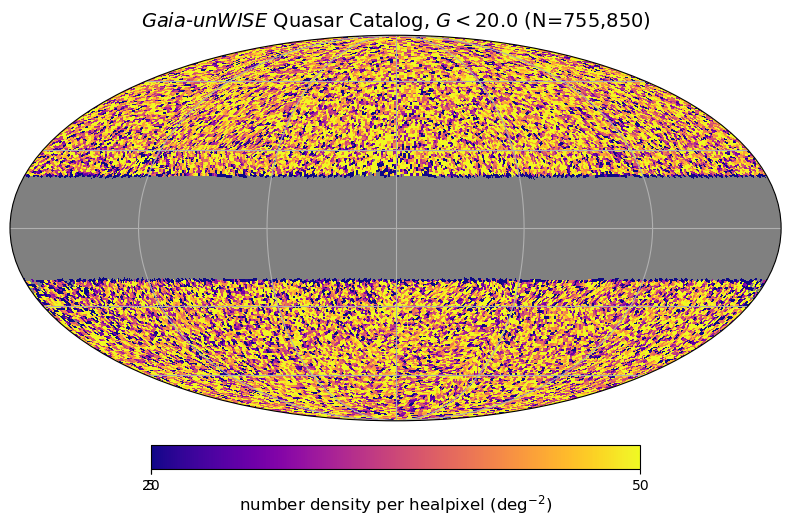

In [63]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, 
                                                                          fn_sello, mask = mask, plot = True, fac_stdev = fac_stdev)

In [64]:
wp_data = quaia.w_theta(tab_datalo[mask_datalo], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_datalo_mask, pixel_indices_randlo_mask, 
                        N_datalo_mask, N_randlo_mask, RR_counts, nthreads = nthreads, thetabins = thetabins)

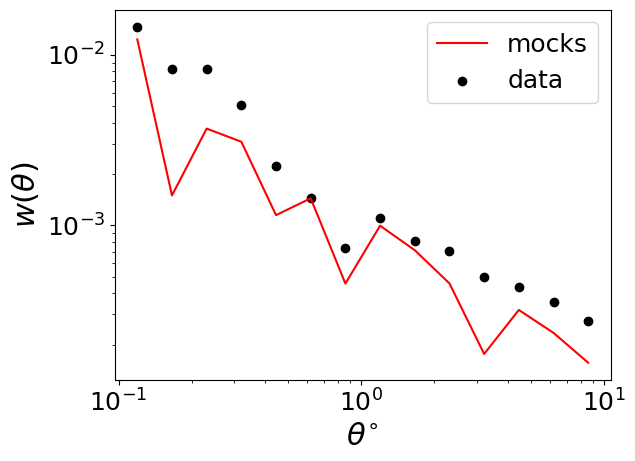

In [65]:
plt.plot(quaia.recenter(thetabins), wp_mock, label = 'mocks', color = 'red')
plt.scatter(quaia.recenter(thetabins), wp_data, label = 'data', color = 'black')
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

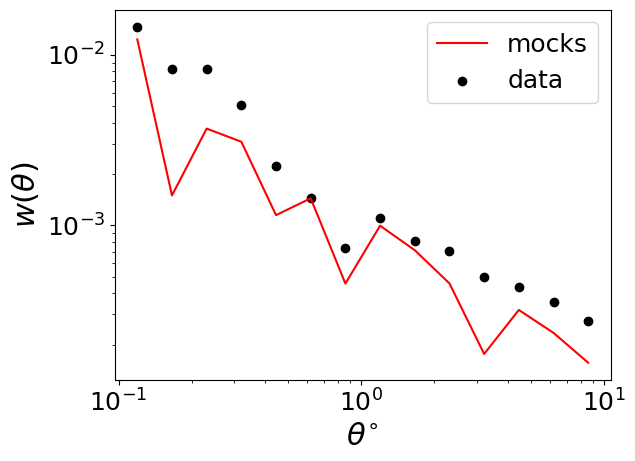

In [66]:
plt.plot(quaia.recenter(thetabins), wp_mock, label = 'mocks', color = 'red')
plt.scatter(quaia.recenter(thetabins), wp_data, label = 'data', color = 'black')
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

## Average the mocks

In [67]:
wp_mocks = []
for i in range(1,31):
    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, G_lo, 
                                                                                           fn_sello, mask = mask)
    wp_mock = quaia.w_theta(tab_gcatlo_i[mask_gcatlo_i], tab_randlo[mask_randlo], selfunc_lo, pixel_indices_gcatlo_mask_i, pixel_indices_randlo_mask, 
                            N_gcatlo_mask_i, N_randlo_mask, RR_counts, nthreads = nthreads, thetabins = thetabins)
    wp_mocks.append(wp_mock)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra

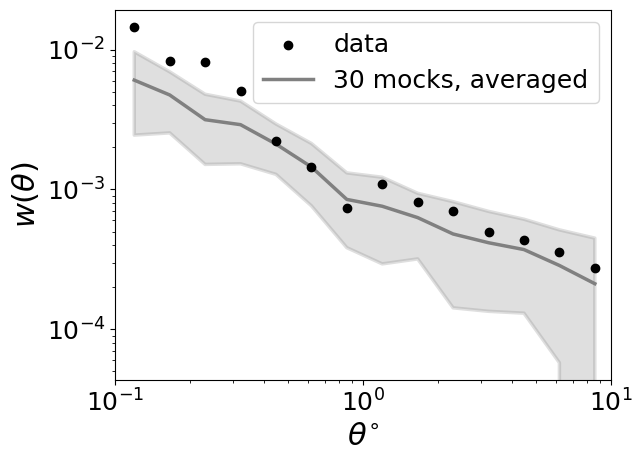

In [68]:
wp_mocks_mean = np.mean(wp_mocks, axis = 0)
yerr = np.std(wp_mocks, axis = 0)

plt.scatter(quaia.recenter(thetabins), wp_data, label = 'data', color = 'black', zorder = 3)
plt.fill_between(quaia.recenter(thetabins), y1 = wp_mocks_mean - yerr, y2 = wp_mocks_mean + yerr, color = 'gray', linewidth = 2.5, alpha = 0.25)
plt.plot(quaia.recenter(thetabins), wp_mocks_mean, label = '30 mocks, averaged', color = 'gray', linewidth = 2.5)

plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(thetabins[0], thetabins[-1]) # bbox_to_anchor=(1, 0.25, 0.5, 0.5)
plt.show()

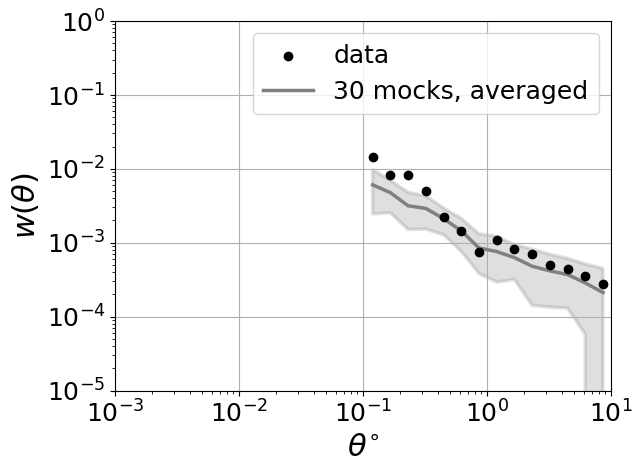

In [69]:
wp_mocks_mean = np.mean(wp_mocks, axis = 0)
yerr = np.std(wp_mocks, axis = 0)

plt.scatter(quaia.recenter(thetabins), wp_data, label = 'data', color = 'black', zorder = 3)
plt.fill_between(quaia.recenter(thetabins), y1 = wp_mocks_mean - yerr, y2 = wp_mocks_mean + yerr, color = 'gray', linewidth = 2.5, alpha = 0.25)
plt.plot(quaia.recenter(thetabins), wp_mocks_mean, label = '30 mocks, averaged', color = 'gray', linewidth = 2.5)

plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(1e-3, 10)
plt.ylim(1e-5, 1)
plt.grid()
plt.show()

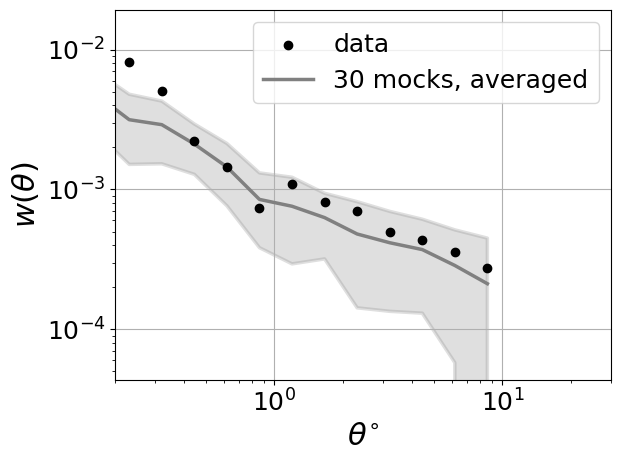

In [70]:
wp_mocks_mean = np.mean(wp_mocks, axis = 0)
yerr = np.std(wp_mocks, axis = 0)

plt.scatter(quaia.recenter(thetabins), wp_data, label = 'data', color = 'black', zorder = 3)
plt.fill_between(quaia.recenter(thetabins), y1 = wp_mocks_mean - yerr, y2 = wp_mocks_mean + yerr, color = 'gray', linewidth = 2.5, alpha = 0.25)
plt.plot(quaia.recenter(thetabins), wp_mocks_mean, label = '30 mocks, averaged', color = 'gray', linewidth = 2.5)

plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(0.2, 30)
plt.grid()
plt.show()

## Check impact of masking

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:93: RuntimeWarning: invalid value encountered in true_divide
  cbar_ticks=[5, 10, 20])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


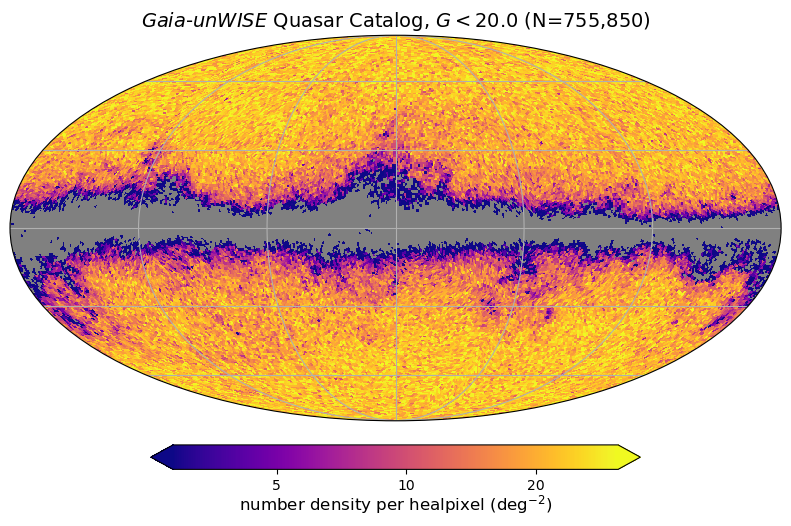

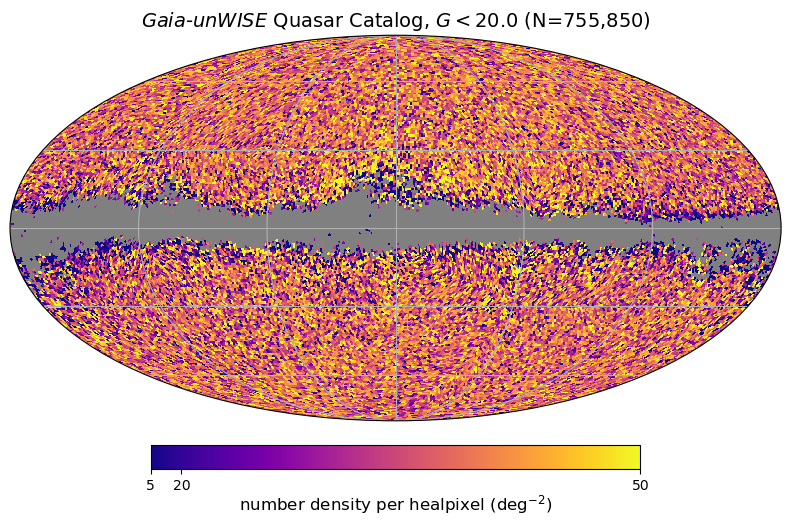

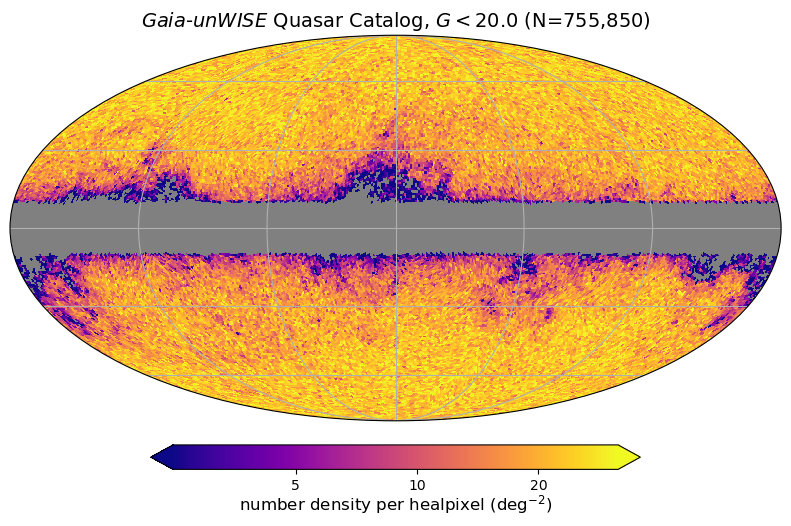

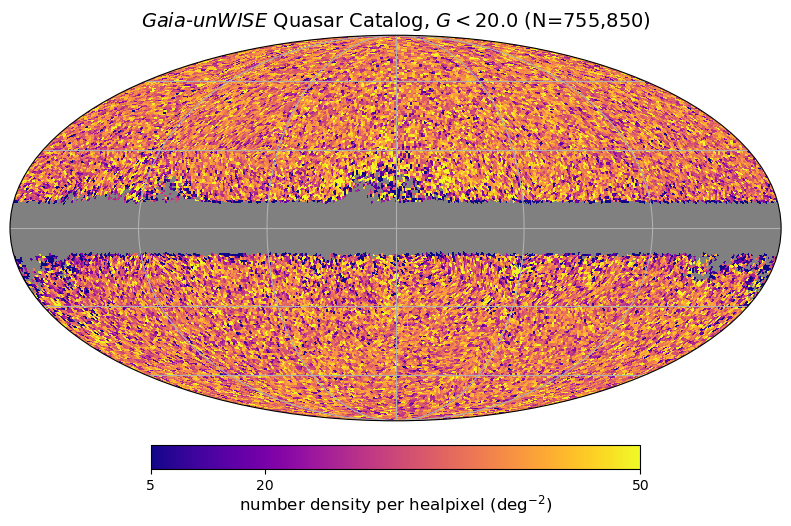

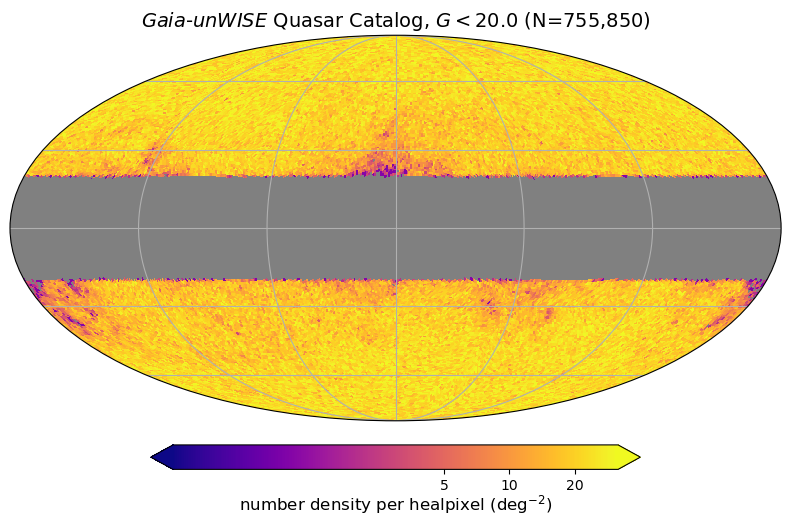

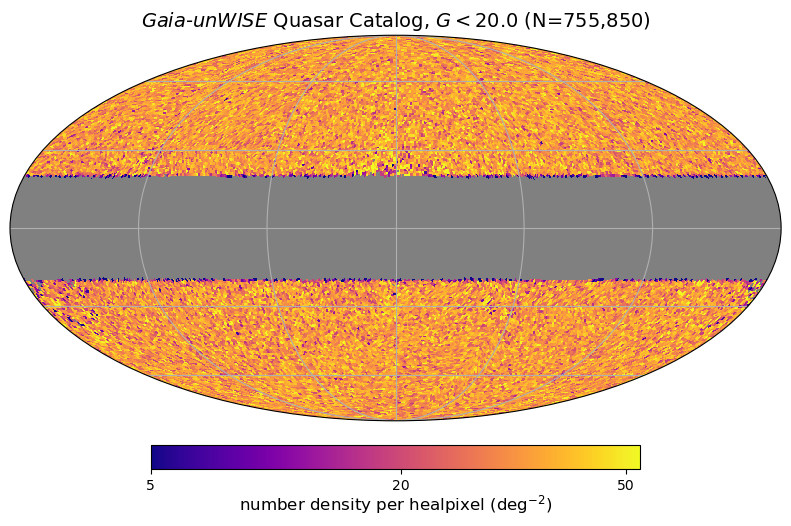

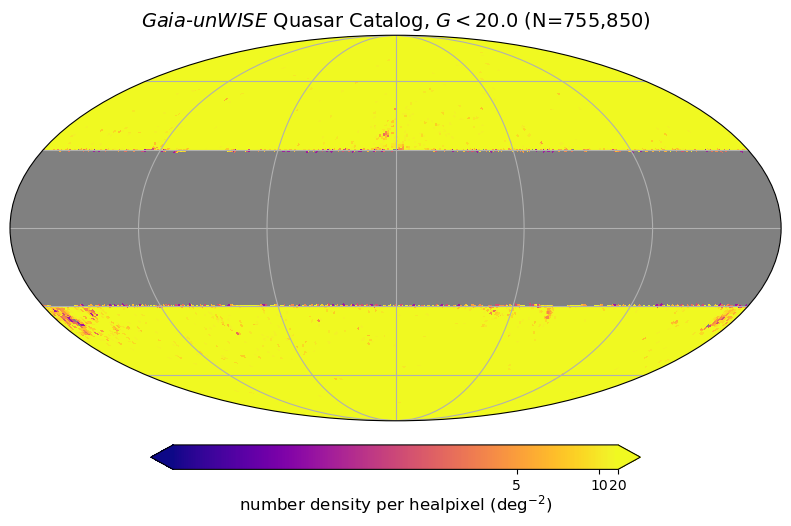

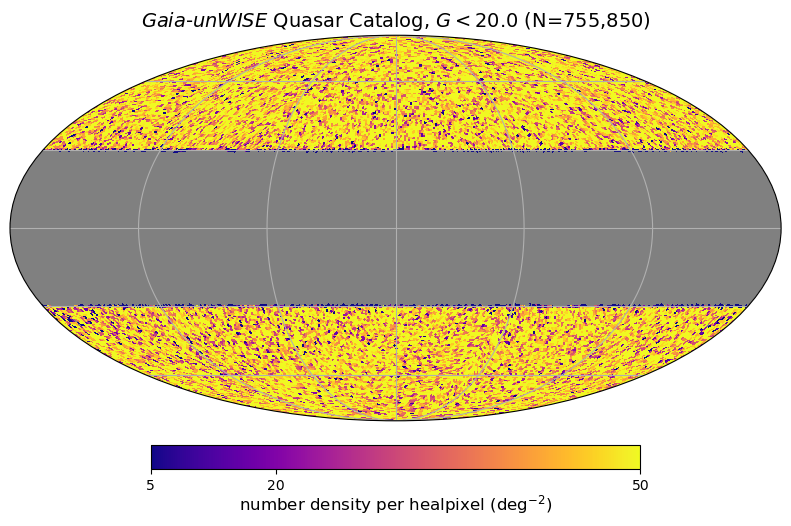

In [71]:
wp_data_b_array = []
b_array = [0, 10, 20, 30]
fac_stdev_array = [1.5, 1.5, 1.45, 0.5] #1.45, 0.5
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, 
                                                                mask = b_array[i], plot = True, fac_stdev = fac_stdev_array[i])

    mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, mask = b_array[i])
    
    pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    wp_data_b = quaia.w_theta(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], selfunc_lo, pixel_indices_datalo_b, pixel_indices_randlo_b, 
                        N_datalo_b, N_randlo_b, None, nthreads = nthreads, thetabins = thetabins)
    
    wp_data_b_array.append(wp_data_b)

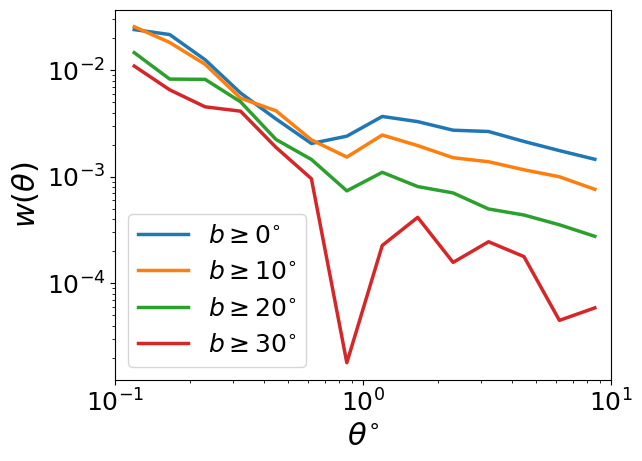

In [72]:
for i in range(len(b_array)):
    plt.plot(quaia.recenter(thetabins), wp_data_b_array[i], label = '$b\geq{:d}^{{\circ}}$'.format(b_array[i]),linewidth = 2.5)
plt.xlabel(r'$\theta^{\circ}$')
plt.ylabel(r"$w(\theta)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(thetabins[0], thetabins[-1]) # bbox_to_anchor=(1, 0.25, 0.5, 0.5)
plt.show()